# CSCI E-89: Homework 4

Paul Schwartzberg

## Problem 1: recognise handwritten digits

Adapted from the course notebook `1_pytorch_basic_cnn_digits.ipynb`. We replace scikit-learn's 8 x 8 digit images with MNIST images from torchvision. Each MNIST image has 28 x 28 pixels.

**Progress:** load and inspect the data. Training, evaluation and inference on my own handwriting will follow.

### 1. Set up the environment

Use the `cscie89` kernel. The printed Python path lets us check that the notebook uses the intended environment. A convolutional neural network (CNN) learns image features through filters whose weights change during training.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision import datasets, transforms

# Fixed seeds make later splits and model initialisation more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python executable: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"Device: {device}")

Python executable: C:\Users\schwa\.conda\envs\cscie89\python.exe
PyTorch: 2.14.0+cpu
torchvision: 0.29.0+cpu
Device: cpu


### 2. Load MNIST through torchvision

A `Dataset` provides an image and its label when we request an item. `datasets.MNIST` supplies the images; `ToTensor()` converts them to the format PyTorch needs.

MNIST has 60,000 training images and 10,000 test images. <br>
We will later divide the training pool into training and validation sets. <br> The test set stays separate until final evaluation.

The shape `(1, 28, 28)` means one colour channel, 28 rows and 28 columns. <br>
Labels are integers from 0 to 9. <br> The first run downloads the data; later runs reuse the local files.

In [2]:
# ToTensor converts each greyscale image to a float tensor of shape
# (1, 28, 28) and scales its pixel values from 0-255 to 0-1.
transform = transforms.ToTensor()
DATA_DIR = Path("data")

mnist_train_full = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

# Inspect a training example; keep the test set for final evaluation.
image, label = mnist_train_full[0]
print(f"Training pool: {len(mnist_train_full):,} images")
print(f"Test set: {len(mnist_test):,} images")
print(f"One image: {tuple(image.shape)}")
print(f"Tensor type: {image.dtype}")
print(f"Pixel range in this image: {image.min().item():.1f} to {image.max().item():.1f}")
print(f"Label: {label}")

Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


...

MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


### 3. Inspect the images

Show one training example per class to check the labels and appearance.<br>
The digits are bright against a dark background. <br>When we prepare my handwritten digits later, we will match this format.

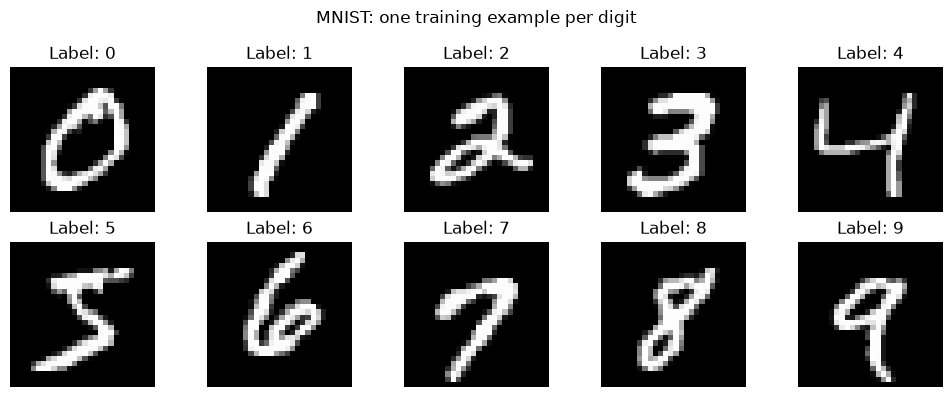

In [3]:
# Show one training image for each digit.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    index = (mnist_train_full.targets == digit).nonzero(as_tuple=True)[0][0].item()
    image, label = mnist_train_full[index]
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
fig.suptitle("MNIST: one training example per digit")
plt.tight_layout()
plt.show()

### Next step

Split the training pool into training and validation sets, then use `DataLoader` objects to serve batches of images to the model.